- Shapefiles for the roadways: https://www.census.gov/cgi-bin/geo/shapefiles/index.php?year=2023&layergroup=Roads
- Shapefiles for the state boundary (need to use cartographic boundary which is land only, o/w the border for NYS will extend into Great Lakes and Atlantic)
    - https://www.census.gov/geographies/mapping-files/time-series/geo/cartographic-boundary.2023.html#list-tab-1883739534
    - 1 : 500,000 (national)  shapefile [3.1 MB]  |  kml [2.4 MB]

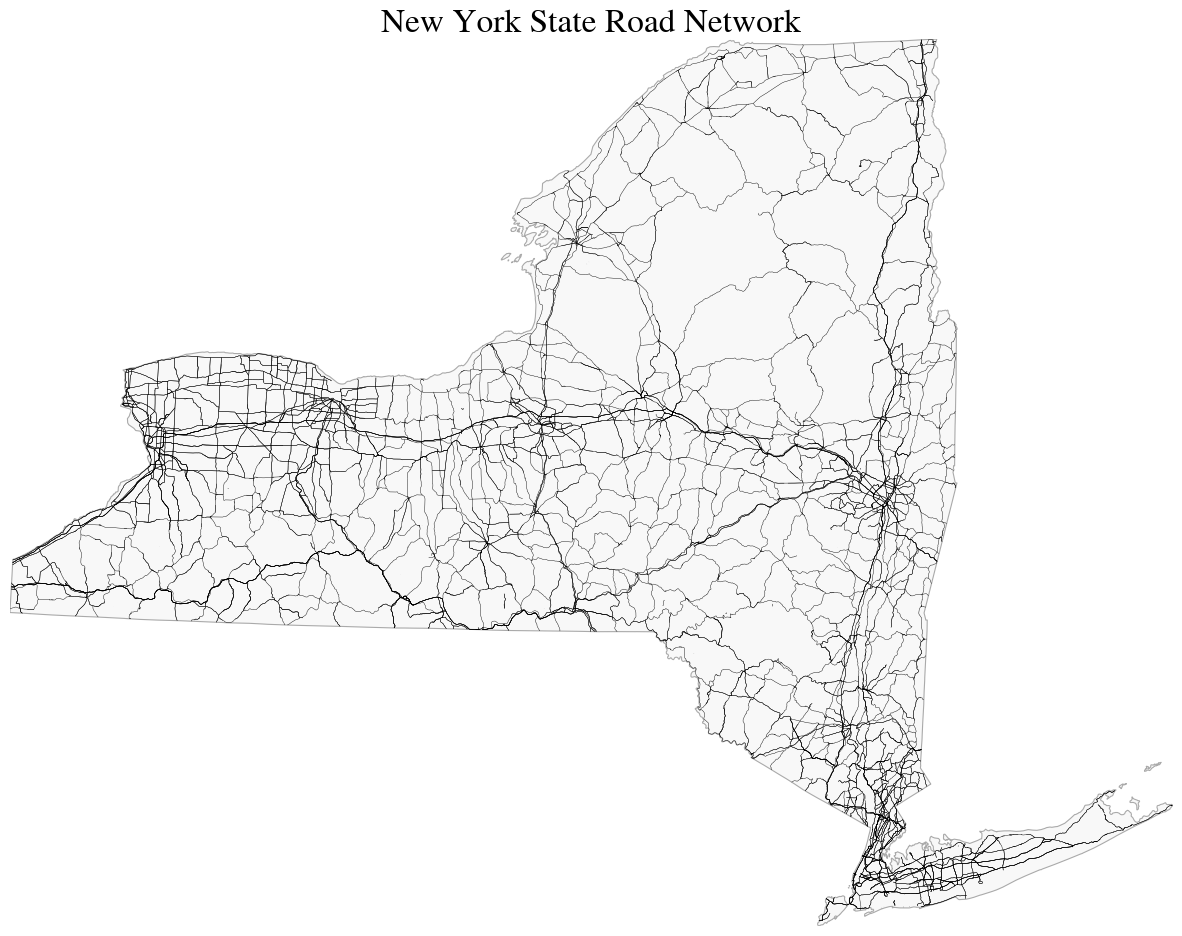

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']

# 1. Load your local files
land_only = gpd.read_file("/home/csutter/DRIVE-clean/data_misc/cb_2023_us_state_500k.zip")
roads = gpd.read_file("/home/csutter/DRIVE-clean/data_misc/tl_2023_36_prisecroads.zip")

# 2. Filter to NY
ny_land = land_only[land_only['STUSPS'] == 'NY']

# 3. USE EPSG:26918 (UTM Zone 18N) 
# This is the "Goldilocks" projection for NY. 
# - It's "Straight": The vertical axis is aligned with the center of the state.
# - It's "Un-smushed": It corrects the vertical scale for the Northern Hemisphere.
ny_land = ny_land.to_crs(epsg=26918)
roads_flat = roads.to_crs(epsg=26918)

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 12))
fig.patch.set_facecolor('white') 

# Plot the land in a very faint grey to act as a container
ny_land.plot(ax=ax, color='#f8f8f8', edgecolor='#aaaaaa', linewidth=0.8, zorder=1)

# Plot the roads in sharp black
roads_flat.plot(ax=ax, color='black', linewidth=0.3, alpha=1.0, zorder=2)

# 5. Clean up and Crop
ax.set_axis_off()
ax.set_aspect('equal')

# Calculate the exact bounds of the state to remove extra white space
# This "crops" the figure to the actual land mass
xmin, ymin, xmax, ymax = ny_land.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Move the title inside or very close to the top
# Using y=0.95 or a small pad keeps it tight to the map
plt.title("New York State Road Network", 
          fontsize=24, fontstyle='normal', pad=5, y=1.0) # pad 5 makes room for the plot title
          
plt.show()